In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI


from dotenv import load_dotenv
import os

In [3]:
load_dotenv()

True

In [4]:
# Read variables
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
OPENAI_API_BASE = os.getenv("OPENAI_API_BASE")

In [6]:
# Create LLM
model = ChatOpenAI(
    openai_api_key=OPENAI_API_KEY,
    openai_api_base=OPENAI_API_BASE,
    model="smallthinker-3b",
    temperature=0.7
)

print(model.invoke("hello"))

content="Hello! How can I assist you today? If you have any questions or need help with something, feel free to ask. Whether it's about general knowledge, specific topics, or just anything else on your mind, I'm here to help. So, what would you like to discuss?" additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 59, 'prompt_tokens': 20, 'total_tokens': 79, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'smallthinker-3b-preview', 'system_fingerprint': 'smallthinker-3b-preview', 'id': 'chatcmpl-ghi95clmh6ai5nepfq5mf8', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019eed82-af12-7c10-adcb-d8a199efd860-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 20, 'output_tokens': 59, 'total_tokens': 79, 'input_token_details': {}, 'output_token_details': {}}


In [5]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

In [7]:

def chat_node(state: ChatState):

    # take user query from state
    messages = state['messages']

    # send to llm
    response = model.invoke(messages)

    # response store state
    return {'messages': [response]}

In [8]:
graph = StateGraph(ChatState)

graph.add_edge(START, 'chat_node')
# add nodes
graph.add_node('chat_node', chat_node)

graph.add_edge('chat_node', END)

chatbot = graph.compile()

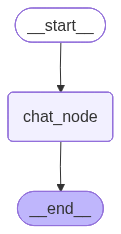

In [9]:
chatbot

In [13]:
initial_state = {
    'messages': [HumanMessage(content='What is the capital of india')]
}

chatbot.invoke(initial_state)['messages'][-1].content

'So I need to find out what the capital of India is. Hmm, I think I know this already, but just to be sure, I should probably confirm it. Let me see.\n\nFirst off, I remember that India is a big country in Asia, and like all countries, it has a capital city where the government is located. I think the capital of India is New Delhi. Yeah, that sounds right. But why do I need to know this? Maybe for a geography test or something like that.\n\nWait a minute, maybe there\'s a chance that people confuse India with another country. I\'ve heard of countries called "India" before, but sometimes they refer to the southern Indian state or other regions as well. So, it\'s important to specify which India we\'re talking about. Like, is it the Republic of India, India as in the subcontinent, or something else?\n\nActually, when people say "India," they usually mean the country that includes states like Delhi, Mumbai, Kolkata, and so on. But just to make sure, maybe I should look it up.\n\nLet me th